# Phase 3: Activation Patching

Phases 1 and 2 left two loose ends:

- **Zero-ablation** (Phase 1) said the most important heads were L0H10 and L1H3, which attend to BOS and punctuation and cannot possibly know about France. Removing them *breaks* the network; it does not test what they know.
- **Direct logit attribution** (Phase 2) only sees the *direct* path from a component to the output. If L8H11 mostly exists to feed L9H8, DLA under-counts it.

**Activation patching** fixes both. Run the model on two prompts that differ only in the fact being recalled, then, on the *corrupted* run, overwrite one activation with its value from the *clean* run and see how much of the clean answer comes back. The network stays in-distribution (every activation is one it produced itself), and because we are intervening rather than reading, indirect effects count.

| | clean | corrupted |
|---|---|---|
| prompt | The capital of Germany is Berlin. The capital of **France** is | The capital of Germany is Berlin. The capital of **Italy** is |
| answer | Paris | Rome |

Metric: logit(Paris) − logit(Rome), normalized so that **0 = corrupted behavior, 1 = fully restored clean behavior.**

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(""))          # experiments/ on the path
sys.path.insert(0, os.path.abspath("experiments"))  # when run from repo root
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)
import torch, numpy as np, pandas as pd
import plotly.express as px, plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "png"          # static images: render on GitHub, no JS needed
pio.templates.default = "plotly_white"
from interp_utils import *
print(f"device={DEVICE}")

device=mps


In [2]:
model = load_gpt2()
paris, rome = answer_ids(model)
clean_tokens, corrupt_tokens = model.to_tokens(CLEAN_PROMPT), model.to_tokens(CORRUPT_PROMPT)
str_toks = model.to_str_tokens(clean_tokens[0])
assert clean_tokens.shape == corrupt_tokens.shape
clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_tokens)
CLEAN_LD, CORRUPT_LD = logit_diff(clean_logits, paris, rome).item(), logit_diff(corrupt_logits, paris, rome).item()
print(f"clean logit diff = {CLEAN_LD:+.2f}   corrupted logit diff = {CORRUPT_LD:+.2f}")

def normalized(logits):
    return (logit_diff(logits, paris, rome).item() - CORRUPT_LD) / (CLEAN_LD - CORRUPT_LD)

def patch(hook_name, positions=None, heads=None):
    # Run the corrupted prompt with one activation replaced by its clean value.
    def hook(act, hook):
        src = clean_cache[hook.name]
        if heads is not None:       # act: [batch, pos, head, d_head]
            act[:, :, heads] = src[:, :, heads]
        elif positions is not None:
            act[:, positions] = src[:, positions]
        else:
            act[:] = src
        return act
    return normalized(model.run_with_hooks(corrupt_tokens, fwd_hooks=[(hook_name, hook)]))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
clean logit diff = +6.05   corrupted logit diff = -6.42


## 1. Where is the information? Residual stream patching by layer and position

The most basic question: at each layer, *which token position* holds the information that distinguishes France from Italy? Patch the residual stream at one (layer, position) and measure recovery.

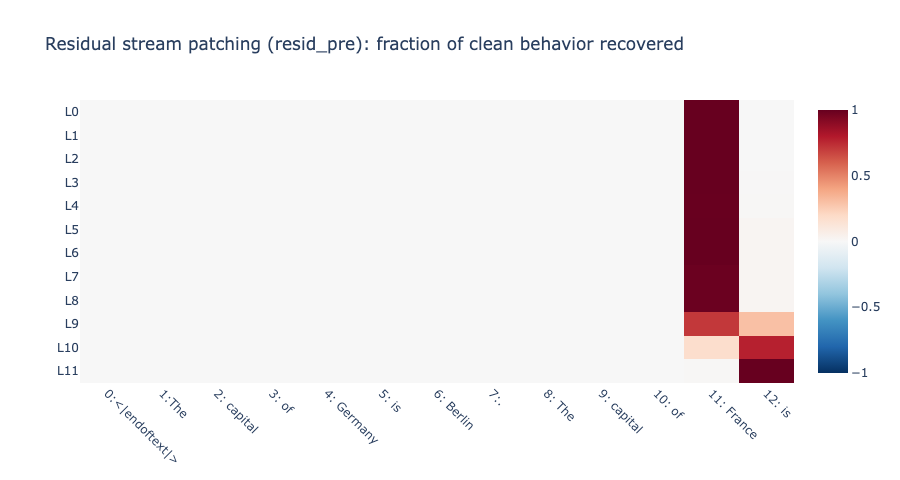

In [3]:
n_pos = clean_tokens.shape[1]
resid_patch = torch.zeros(12, n_pos)
for layer in range(12):
    for pos in range(n_pos):
        resid_patch[layer, pos] = patch(f"blocks.{layer}.hook_resid_pre", positions=pos)

fig = px.imshow(resid_patch.numpy(), x=[f"{i}:{t}" for i, t in enumerate(str_toks)], y=[f"L{l}" for l in range(12)],
                color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto",
                title="Residual stream patching (resid_pre): fraction of clean behavior recovered")
fig.update_layout(width=900, height=480, xaxis_tickangle=45); fig.show()

This is the cleanest picture in the repo. The France-vs-Italy information lives **entirely at the country token** from the embedding through layer 8: patch that one position and you recover 100% of the answer; patch anything else and you get nothing. Then, across layers 9 and 10, it **moves to the final position** (0.71 → 0.18 at the country token; 0.30 → 0.78 → 1.0 at the answer token). By layer 11 the country token no longer matters.

Two positions, one hand-off. Everything in the demonstration line (" Germany", " Berlin") contributes nothing to *which* capital is produced; it only sets up the format.

## 2. Who moves it? Attention blocks vs MLPs at the answer position

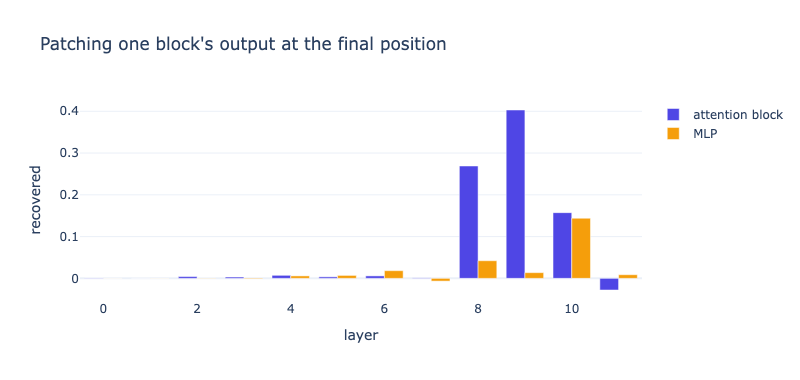

attention: [0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.01, 0.0, 0.27, 0.4, 0.16, -0.03]
MLP:       [0.0, -0.0, 0.0, -0.0, 0.01, 0.01, 0.02, -0.01, 0.04, 0.01, 0.14, 0.01]


In [4]:
attn_rec = [patch(f"blocks.{l}.hook_attn_out", positions=-1) for l in range(12)]
mlp_rec  = [patch(f"blocks.{l}.hook_mlp_out",  positions=-1) for l in range(12)]
fig = go.Figure()
fig.add_bar(name="attention block", x=list(range(12)), y=attn_rec, marker_color="#4f46e5")
fig.add_bar(name="MLP",             x=list(range(12)), y=mlp_rec,  marker_color="#f59e0b")
fig.update_layout(barmode="group", width=800, height=380, title="Patching one block's output at the final position",
                  xaxis_title="layer", yaxis_title="recovered")
fig.show()
print("attention:", [round(v, 2) for v in attn_rec]); print("MLP:      ", [round(v, 2) for v in mlp_rec])

The hand-off is done by **attention** in layers 8, 9 and 10 (27%, 40%, 16% recovered from a single block each). MLPs do almost nothing on this metric except a modest 14% at layer 10, consistent with Phase 2: the MLPs make " Paris" more probable in general, but they are not what tells France from Italy.

## 3. Which heads? Per-head patching

Patch one head's output (`hook_z`, at all positions) from clean into corrupted.

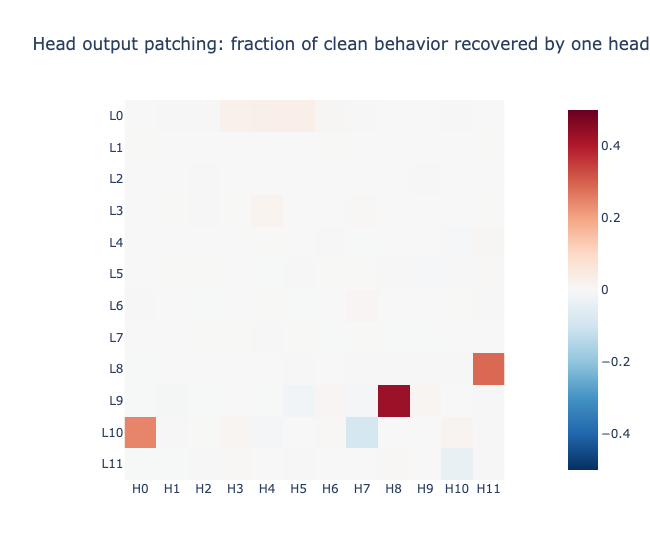

  L9H8    +0.43
  L8H11   +0.29
  L10H0   +0.25
  L10H7   -0.09
  L11H10  -0.04
  L0H5    +0.03
  L0H4    +0.03
  L0H3    +0.03


In [5]:
head_patch = torch.zeros(12, 12)
for layer in range(12):
    for head in range(12):
        head_patch[layer, head] = patch(f"blocks.{layer}.attn.hook_z", heads=head)

fig = px.imshow(head_patch.numpy(), x=[f"H{h}" for h in range(12)], y=[f"L{l}" for l in range(12)],
                color_continuous_scale="RdBu_r", zmin=-0.5, zmax=0.5,
                title="Head output patching: fraction of clean behavior recovered by one head")
fig.update_layout(width=650, height=560); fig.show()
ranked = sorted([(f"L{l}H{h}", head_patch[l, h].item()) for l in range(12) for h in range(12)], key=lambda x: -abs(x[1]))
for n, v in ranked[:8]: print(f"  {n:7s} {v:+.2f}")

### Three methods, one table

Now we can put the three attribution methods side by side for the heads that any of them flagged.

In [6]:
# zero-ablation effect (from Phase 1, recomputed) and DLA (from Phase 2)
direction = logit_diff_direction(model)
dla, _ = per_head_dla(model, clean_cache, direction)
zero_abl = torch.zeros(12, 12)
for layer in range(12):
    for head in range(12):
        def zero_head(z, hook, head=head):
            z[:, :, head] = 0; return z
        out = model.run_with_hooks(clean_tokens, fwd_hooks=[(f"blocks.{layer}.attn.hook_z", zero_head)])
        zero_abl[layer, head] = CLEAN_LD - logit_diff(out, paris, rome).item()

rows = []
for l, h in [(9, 8), (8, 11), (10, 0), (10, 7), (11, 10), (0, 10), (1, 3), (5, 9)]:
    rows.append(dict(head=f"L{l}H{h}", zero_ablation=round(zero_abl[l, h].item(), 2), DLA=round(dla[l, h].item(), 2),
                     patching=round(head_patch[l, h].item(), 2),
                     attends_to=max(zip(clean_cache[f"blocks.{l}.attn.hook_pattern"][0, h, -1].tolist(), str_toks))[1]))
pd.DataFrame(rows)

,head,zero_ablation,DLA,patching,attends_to
0,L9H8,1.72,2.58,0.43,France
1,L8H11,2.56,1.37,0.29,France
2,L10H0,1.04,1.09,0.25,France
3,L10H7,-0.32,-0.35,-0.09,Berlin
4,L11H10,-0.38,-0.36,-0.04,<|endoftext|>
5,L0H10,3.66,-0.10,0.00,is
6,L1H3,1.86,-0.02,-0.00,<|endoftext|>
7,L5H9,1.26,-0.01,-0.00,<|endoftext|>


- **L9H8, L8H11, L10H0** are the circuit. All three methods agree, and patching ranks them in the same order as DLA (0.43, 0.29, 0.25 of the behavior recovered by a single head).
- **L0H10, L1H3, L5H9** were the top zero-ablation hits. Under patching they are at 0.03 or below. They are load-bearing plumbing, not France detectors, and zero-ablation could not tell the difference.
- **L10H7, L11H10** are negative under every method: the suppressor heads from Phase 2, confirmed causally.

Note the sum: the three main heads together recover about 97% of the behavior. There is no hidden fourth mechanism.

## 4. Inside L9H8: is it *where it looks* or *what it copies*?

A head's output depends on its attention pattern (QK) and on the values it reads (OV). Patching lets us separate them. On the corrupted (Italy) run:

- **patch the pattern only**: L9H8 attends where it did on the clean run, but reads Italy's values. If the pattern is all that differs, this restores the answer.
- **patch the values only**: L9H8 attends as it does on the Italy run, but the values it reads are France's.

In [7]:
def patch_head_pattern(layer, head):
    def hook(pat, hook):
        pat[:, head] = clean_cache[hook.name][:, head]; return pat
    return normalized(model.run_with_hooks(corrupt_tokens, fwd_hooks=[(f"blocks.{layer}.attn.hook_pattern", hook)]))
def patch_head_values(layer, head):
    def hook(v, hook):
        v[:, :, head] = clean_cache[hook.name][:, :, head]; return v
    return normalized(model.run_with_hooks(corrupt_tokens, fwd_hooks=[(f"blocks.{layer}.attn.hook_v", hook)]))

for l, h in [(9, 8), (8, 11), (10, 0)]:
    print(f"L{l}H{h}: patch attention pattern → {patch_head_pattern(l, h):+.2f}   patch values → {patch_head_values(l, h):+.2f}   patch full output → {head_patch[l, h]:+.2f}")
clean_pat = clean_cache["blocks.9.attn.hook_pattern"][0, 8, -1]; corr_pat = corrupt_cache["blocks.9.attn.hook_pattern"][0, 8, -1]
print("\nL9H8 attention from the final token, clean vs corrupted:")
for t, a, b in zip(str_toks, clean_pat, corr_pat):
    if max(a, b) > 0.03: print(f"  {t!r:14s} {a:.2f}  {b:.2f}")

L9H8: patch attention pattern → +0.01   patch values → +0.46   patch full output → +0.43
L8H11: patch attention pattern → +0.02   patch values → +0.32   patch full output → +0.29
L10H0: patch attention pattern → +0.06   patch values → +0.34   patch full output → +0.25

L9H8 attention from the final token, clean vs corrupted:
  ' Germany'     0.08  0.03
  ' France'      0.88  0.96


Patching the attention pattern does **nothing**, and patching the values recovers the head's full effect. That is because the pattern is the *same* on both prompts: L9H8 attends ~90% to whatever sits at the country position regardless of which country it is. The head's QK circuit implements "look at the country slot"; all of the France-vs-Italy information is in what it *reads* there. This is what a general-purpose routing head looks like: fixed wiring, variable payload.

## 5. What we learned

**The circuit, causally.** The country's identity is written at the country token by the embedding and early layers and stays there until layer 8. Three heads (L8H11, L9H8, L10H0) with fixed "look at the country slot" attention copy it into the answer position across layers 8 to 10, where the unembedding reads it out. Two late heads (L10H7, L11H10) push back. Together the three copy heads account for ~97% of the France-vs-Italy behavior.

**On methods.** Zero-ablation confounds "carries the information" with "is structurally necessary"; DLA misses indirect effects; patching handles both, at the cost of needing a matched counterfactual prompt. Designing that counterfactual (same length, same format, only the fact changed) is most of the skill.

**What patching cannot tell you.** It says *which* activations matter, not *what they mean*. The residual stream at the country token carries "France", but as a 768-dimensional vector in superposition with everything else. Reading that vector is the job of **sparse autoencoders**, Phase 4.

In [8]:
# PLAYGROUND
# - Change CORRUPT_PROMPT to Japan/Tokyo. Does the same hand-off happen at the same layers?
# - Patch hook_resid_pre at the country token *and* at the final token together at layer 9. Additive?
# - Path patching: patch L8H11's output only where it feeds L9H8's value input (hook_v at layer 9, country position).